In [ ]:
!pip install -q -U langgraph langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.7/571.7 kB 7.2 MB/s eta 0:00:00


In [ ]:
pip install mcp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.7/365.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 6.4 MB/s eta 0:00:00


In [ ]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. Define the Graph State schema
class AgentState(TypedDict):
    user_query: str
    response: str
    is_valid: bool

In [ ]:
# 2. Define Node Functions
def generate_response_node(state: AgentState):
    query = state["user_query"]
    # Simulating LLM output generation
    simulated_answer = f"Processed request: {query.upper()}"
    return {"response": simulated_answer}
def validation_node(state: AgentState):
    # Validates if response meets basic length requirements
    valid = len(state["response"]) > 10
    return {"is_valid": valid}

In [ ]:
#3. Define Routing Logic (Conditional Edge)
def router(state: AgentState):
    if state["is_valid"]:
        return "approved"
    else:
        return "rejected"

In [ ]:
# 4. Build the LangGraph State Machine
builder = StateGraph(AgentState)

# Add Nodes
builder.add_node("generator", generate_response_node)
builder.add_node("validator", validation_node)

# Wire Edges
builder.add_edge(START, "generator")
builder.add_edge("generator", "validator")

# Conditional Routing
builder.add_conditional_edges(
    "validator",
    router,
    {
        "approved": END,
        "rejected": "generator"  # Loops back if validation fails!
    }
)

app = builder.compile()

In [ ]:
# 5. Execute Graph
output = app.invoke({"user_query": "hello langgraph agent"})
print("--- LANGGRAPH EXECUTION COMPLETE ---")
print(f"Final State: {output}")

--- LANGGRAPH EXECUTION COMPLETE ---
Final State: {'user_query': 'hello langgraph agent', 'response': 'Processed request: HELLO LANGGRAPH AGENT', 'is_valid': True}


In [ ]:
!pip uninstall -y mcp mcp-types
!pip cache purge


Found existing installation: mcp 2.2.0
Uninstalling mcp-2.2.0:
  Successfully uninstalled mcp-2.2.0
Found existing installation: mcp-types 2.2.0
Uninstalling mcp-types-2.2.0:
  Successfully uninstalled mcp-types-2.2.0
Files removed: 18


In [ ]:
import importlib.metadata
print(importlib.metadata.version("mcp"))

PackageNotFoundError: No package metadata was found for mcp

In [ ]:
!pip uninstall -y mcp fastmcp langchain-mcp-adapters langgraph langchain-google-genai
!pip install -q "mcp>=1.0.0,<2.0.0" mcp-types langgraph langchain-google-genai nest_asyncio

Found existing installation: langgraph 1.2.11
Uninstalling langgraph-1.2.11:
  Successfully uninstalled langgraph-1.2.11
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.6/234.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.9/248.9 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 26.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-au

In [ ]:
import os
import csv
import asyncio
import nest_asyncio
from google.colab import userdata

# LangChain & LangGraph Imports
from langchain_core.tools import StructuredTool
from langgraph.prebuilt import create_react_agent
from langchain_google_genai import ChatGoogleGenerativeAI

nest_asyncio.apply()

# 1. Setup Gemini API Key from Colab Secrets
os.environ["GOOGLE_API_KEY"] = userdata.get("Gemini_API_Key")

# 2. Initialize Gemini LLM (Use valid model name)
llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash", temperature=0)

# -------------------------------------------------------------
# 3. Local Real-World Tools (MCP Primitive Logic)
# -------------------------------------------------------------
CSV_FILE = "expenses.csv"

def _initialize_csv():
    if not os.path.exists(CSV_FILE):
        with open(CSV_FILE, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Item", "Amount", "Category"])

def add_expense(item: str, amount: float, category: str) -> str:
    """Logs a new expense with item, amount, and category into CSV."""
    _initialize_csv()
    with open(CSV_FILE, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([item, amount, category])
    return f"Successfully logged expense: {item} - ${amount} ({category})"

def get_expenses() -> str:
    """Retrieves all logged expenses from the CSV file."""
    _initialize_csv()
    with open(CSV_FILE, mode='r') as f:
        reader = csv.reader(f)
        rows = list(reader)
    if len(rows) <= 1:
        return "No expenses recorded yet."
    return "\n".join([", ".join(row) for row in rows])

# -------------------------------------------------------------
# 4. Wrap Tools as LangChain Structured Tools for LangGraph
# -------------------------------------------------------------
mcp_tools = [
    StructuredTool.from_function(
        func=add_expense,
        name="add_expense",
        description="Logs a new expense with item, amount, and category."
    ),
    StructuredTool.from_function(
        func=get_expenses,
        name="get_expenses",
        description="Retrieves all logged expenses from the expense tracker."
    )
]

# -------------------------------------------------------------
# 5. Build & Execute LangGraph Agent
# -------------------------------------------------------------
agent = create_react_agent(llm, mcp_tools)

async def run_agentic_workflow():
    print("--- Task 1: Log an expense ---")
    prompt_1 = "I bought a Indian food for $16. Category is Food."
    response_1 = await agent.ainvoke({"messages": [("user", prompt_1)]})

    # Correct attribute inspection for LangChain BaseMessage objects
    for msg in response_1["messages"]:
        if msg.type == "ai" and msg.content:
            print(f"\n[Agent Response]: {msg.content}")

    print("\n--- Task 2: Retrieve records ---")
    prompt_2 = "Show me all expenses logged so far."
    response_2 = await agent.ainvoke({"messages": [("user", prompt_2)]})

    for msg in response_2["messages"]:
        if msg.type == "ai" and msg.content:
            print(f"\n[Agent Response]: {msg.content}")

# Run Execution Loop
asyncio.run(run_agentic_workflow())

/tmp/ipykernel_846/1646470217.py:68: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, mcp_tools)
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


--- Task 1: Log an expense ---


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



[Agent Response]: [{'type': 'text', 'text': "I've logged your expense: **Indian food** for **$16.00** under the **Food** category.", 'extras': {'signature': 'ErABCq0BARFNMg8dhAj2C8H0mT41mv2p6QgViiko4boaPGf9SHqB5ysAmxOrD60X5gq3b5H4eEFUkXb/tqpZcrcuNnFtsT+rVZ5kUjPf/nOprpzzB5QWIyia6o9lFVTTzS70J0GP8IXk8oAkaxDz4gneFXg50N+Kydl01eiMRscqd60HfZfXjFBZbXe6wmFwMAHnblkowFy2FJ4pM92vO5ywTVisFU+W7mAyci/OAcvvZiQ='}}]

--- Task 2: Retrieve records ---


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



[Agent Response]: [{'type': 'text', 'text': 'Here are all the expenses logged so far:\n\n1. **Pizza** — $12.50 (*Food*)\n2. **Indian food** — $16.00 (*Food*)\n3. **Indian food** — $16.00 (*Food*)\n\n**Total Expenses:** $44.50', 'extras': {'signature': 'EooCCocCARFNMg863zgpOdRWSrvTzE3k9GC5oTFMOnIIEIDLJPijgFcMvkRsRTjq6YShEJ+H6Si6H0iUyQykT0FxTttGyyh43z1PaWTPrGctMDsfyk5ov43VOCSNaUPFfMoUzjO5daYaZzo6Ii+lU/xxwlUofixvfSZXXMQrg3LKMulAPBd+wZwoNgGO5udp+i/FMaxLK7jntIN+kVfpsJzDwbU7H2L5Zw+IpA78oLcxToixezLasa7gGKkX3rzt2fgGkmHhGsObhoQcfW84Ml9UY+rA0zU4eJCFYPFWkUVZnD6jHhbXfx8YOkHnLsrn+SgUKl7XVc9dstlnwn4Q+C7yOVlpkYChFpkB1Cw='}}]


In [ ]:
import os
import csv
import asyncio
import nest_asyncio
from google.colab import userdata

from langchain_core.tools import StructuredTool
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

nest_asyncio.apply()

# 1. API & Model Setup
os.environ["GOOGLE_API_KEY"] = userdata.get("Gemini_API_Key")
llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash")

# 2. Expense Tools
CSV_FILE = "expenses.csv"

def _initialize_csv():
    if not os.path.exists(CSV_FILE):
        with open(CSV_FILE, mode='w', newline='') as f:
            csv.writer(f).writerow(["Item", "Amount", "Category"])

def add_expense(item: str, amount: float, category: str) -> str:
    _initialize_csv()
    with open(CSV_FILE, mode='a', newline='') as f:
        csv.writer(f).writerow([item, amount, category])
    return f"Logged: {item} - ${amount} ({category})"

def get_expenses() -> str:
    _initialize_csv()
    with open(CSV_FILE, mode='r') as f:
        rows = list(csv.reader(f))
    return "No expenses." if len(rows) <= 1 else "\n".join([", ".join(r) for r in rows[1:]])

# 3. Wrap Tools & Build Agent
mcp_tools = [
    StructuredTool.from_function(func=add_expense, name="add_expense", description="Logs an expense."),
    StructuredTool.from_function(func=get_expenses, name="get_expenses", description="Gets logged expenses.")
]

agent = create_agent(llm, mcp_tools)

# 4. Helper to extract raw text string
def get_clean_text(content) -> str:
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        return "".join([b.get("text", "") for b in content if isinstance(b, dict) and b.get("type") == "text"])
    return str(content)

# 5. Execution
async def run_agentic_workflow():
    res1 = await agent.ainvoke({"messages": [("user", "I bought a Indian food for $16. Category is Food.")]})
    print(get_clean_text(res1["messages"][-1].content))

    res2 = await agent.ainvoke({"messages": [("user", "Show me all expenses logged so far.")]})
    print(get_clean_text(res2["messages"][-1].content))

asyncio.run(run_agentic_workflow())

I've logged your expense of $16.00 for Indian food under the Food category.
Here are all the expenses logged so far:

1. **Pizza** — $12.50 (*Food*)
2. **Indian food** — $16.00 (*Food*)
3. **Indian food** — $16.00 (*Food*)
4. **Indian food** — $16.00 (*Food*)

**Total Expenses:** $60.50


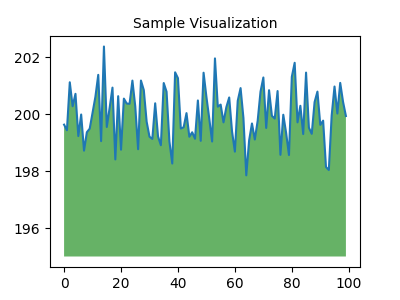

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)